# Alignment v2 result map

This notebook maps every stage of the active Alignment v2 Slurm pipeline. Each code cell has an `alignment-v2-<stage>` tag. Slurm executes only the cell associated with the completed task and writes an isolated notebook under `results/alignment_v2/notebooks/`; the final report job executes the complete notebook.

The notebook is safe before results exist: missing artifacts are reported as pending rather than treated as zero-valued results.

In [1]:
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path(os.environ.get('ALIGNMENT_V2_ROOT', Path.cwd())).resolve()
if not (ROOT / 'configs/alignment_v2/pipeline.yaml').exists() and (ROOT.parent / 'configs/alignment_v2/pipeline.yaml').exists():
    ROOT = ROOT.parent
RESULTS = ROOT / 'results/alignment_v2'
CHECKPOINTS = ROOT / 'checkpoints/alignment_v2'
STAGE = os.environ.get('ALIGNMENT_V2_NOTEBOOK_STAGE', 'interactive')
_raw_index = os.environ.get('ALIGNMENT_V2_NOTEBOOK_INDEX')
ARRAY_INDEX = int(_raw_index) if _raw_index not in (None, '', 'main') else None
pd.set_option('display.max_columns', 100)
plt.style.use('seaborn-v0_8-whitegrid')

def read_json(path):
    path = Path(path)
    return json.loads(path.read_text()) if path.exists() else None

def read_csv(path):
    path = Path(path)
    return pd.read_csv(path) if path.exists() else pd.DataFrame()

def show_pending(message):
    display(Markdown(f'> **Pending:** {message}'))

print(f'project={ROOT}')
print(f'stage={STAGE} array_index={ARRAY_INDEX}')

project=/mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm
stage=train array_index=4


## 1. Validation and experiment map

Shows the validated reference and frozen-unimodal job manifests produced by `00_validate.sbatch`.

In [ ]:
validation = read_json(RESULTS / 'manifests/validation.json')
references = read_csv(RESULTS / 'manifests/reference_jobs.csv')
unimodal = read_csv(RESULTS / 'manifests/unimodal_jobs.csv')
if validation is None:
    show_pending('validation.json has not been generated.')
else:
    display(pd.DataFrame([validation]))
    display(Markdown(f'**Planned workload:** {len(references)} paired reference job and {len(unimodal)} frozen-unimodal runs.'))
    display(references)
    display(unimodal)

## 2. Pretrained-model prefetch

Maps the shared checkpoint-cache preparation performed by `00b_prefetch.sbatch`.

In [ ]:
prefetch = read_json(RESULTS / 'prefetch.json')
if prefetch is None:
    show_pending('The pretrained-model prefetch has not completed.')
else:
    display(pd.DataFrame([{
        'status': prefetch.get('status'),
        'unique_models': prefetch.get('unique_models'),
        'models': ', '.join(prefetch.get('models', [])),
    }]))

## 3. Paired reference result

Maps retrieval and efficiency measurements from `01_reference_array.sbatch`.

In [ ]:
reference_manifest = read_csv(RESULTS / 'manifests/reference_jobs.csv')
if ARRAY_INDEX is not None and not reference_manifest.empty:
    reference_manifest = reference_manifest[reference_manifest['array_index'] == ARRAY_INDEX]
reference_rows = []
for experiment_id in reference_manifest.get('experiment_id', pd.Series(dtype=str)).astype(str):
    payload = read_json(RESULTS / 'reference' / experiment_id / 'metrics.json')
    if payload is not None:
        reference_rows.append(payload)
reference_frame = pd.DataFrame(reference_rows)
if reference_frame.empty:
    show_pending('No paired-reference metrics are available for this task.')
else:
    columns = [c for c in ['experiment_id', 'i2t_R@1', 'i2t_R@5', 'i2t_R@10', 't2i_R@1', 't2i_R@5', 't2i_R@10', 'mean_R@1', 'bidirectional_pair_latency_ms', 'peak_memory_bytes', 'params_total', 'params_trainable'] if c in reference_frame]
    display(reference_frame[columns])
    recall_columns = [c for c in ['i2t_R@1', 't2i_R@1', 'mean_R@1'] if c in reference_frame]
    if recall_columns:
        ax = reference_frame.set_index('experiment_id')[recall_columns].plot.bar(figsize=(9, 4), rot=0)
        ax.set_ylabel('Recall')
        ax.set_title('Paired reference retrieval')
        plt.tight_layout()
        plt.show()

## 4. Frozen-unimodal training state

Maps checkpoints and any epoch histories produced by `02_train_unimodal_array.sbatch`. For an array task, only its own run is displayed.

,array_index,run_id,seed,best,latest,final,history_rows
0,4,convnext_minilm_residual_mp__seed_43,43,True,True,True,12


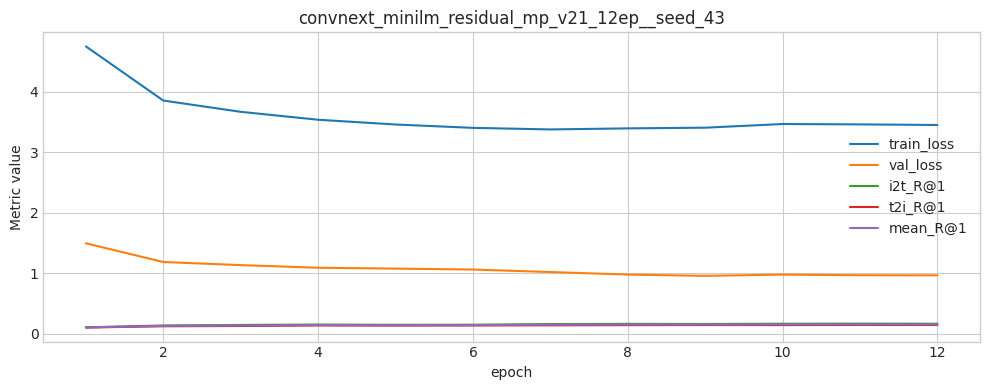

In [2]:
train_manifest = read_csv(RESULTS / 'manifests/unimodal_jobs.csv')
if ARRAY_INDEX is not None and not train_manifest.empty:
    train_manifest = train_manifest[train_manifest['array_index'] == ARRAY_INDEX]
train_rows, histories = [], []
for row in train_manifest.to_dict('records'):
    run_id = str(row['run_id'])
    checkpoint_dir = CHECKPOINTS / run_id
    history_path = checkpoint_dir / 'metrics.csv'
    train_rows.append({
        'array_index': row['array_index'],
        'run_id': run_id,
        'seed': row['seed'],
        'best': (checkpoint_dir / 'best.pt').exists(),
        'latest': (checkpoint_dir / 'latest.pt').exists(),
        'final': (checkpoint_dir / 'final.pt').exists(),
        'history_rows': len(read_csv(history_path)),
    })
    history = read_csv(history_path)
    if not history.empty:
        history['run_id'] = run_id
        histories.append(history)
train_state = pd.DataFrame(train_rows)
if train_state.empty:
    show_pending('The unimodal manifest is unavailable.')
else:
    display(train_state)
if histories:
    history_frame = pd.concat(histories, ignore_index=True)
    x_column = 'epoch' if 'epoch' in history_frame else None
    metric_columns = [c for c in ['train_loss', 'val_loss', 'i2t_R@1', 't2i_R@1', 'mean_R@1'] if c in history_frame]
    if x_column and metric_columns:
        for run_id, run_history in history_frame.groupby('run_id'):
            ax = run_history.plot(x=x_column, y=metric_columns, figsize=(10, 4), title=run_id)
            ax.set_ylabel('Metric value')
            plt.tight_layout()
            plt.show()
else:
    show_pending('No epoch-history CSV is available for the selected training task yet.')

## 5. Frozen-unimodal evaluation

Maps the matched retrieval, latency, parameter, and memory measurements from `03_evaluate_unimodal_array.sbatch`.

In [ ]:
evaluation_manifest = read_csv(RESULTS / 'manifests/unimodal_jobs.csv')
if ARRAY_INDEX is not None and not evaluation_manifest.empty:
    evaluation_manifest = evaluation_manifest[evaluation_manifest['array_index'] == ARRAY_INDEX]
evaluation_rows = []
for run_id in evaluation_manifest.get('run_id', pd.Series(dtype=str)).astype(str):
    payload = read_json(RESULTS / 'unimodal' / run_id / 'metrics.json')
    if payload is not None:
        evaluation_rows.append(payload)
evaluation_frame = pd.DataFrame(evaluation_rows)
if evaluation_frame.empty:
    show_pending('No frozen-unimodal evaluation metrics are available for this task.')
else:
    columns = [c for c in ['experiment_id', 'run_id', 'seed', 'i2t_R@1', 'i2t_R@5', 'i2t_R@10', 't2i_R@1', 't2i_R@5', 't2i_R@10', 'mean_R@1', 'bidirectional_pair_latency_ms', 'peak_memory_bytes', 'params_total', 'params_trainable'] if c in evaluation_frame]
    display(evaluation_frame[columns].sort_values(['experiment_id', 'seed']))
    if {'mean_R@1', 'bidirectional_pair_latency_ms'}.issubset(evaluation_frame.columns):
        fig, ax = plt.subplots(figsize=(8, 5))
        for experiment_id, group in evaluation_frame.groupby('experiment_id'):
            ax.scatter(group['bidirectional_pair_latency_ms'], group['mean_R@1'], label=experiment_id, s=70)
        ax.set_xlabel('Batch-one bidirectional latency (ms)')
        ax.set_ylabel('Mean bidirectional R@1')
        ax.set_title('Accuracy–latency map')
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.show()

## 6. Pipeline completion status

Combines Slurm state markers with expected result/checkpoint targets.

In [ ]:
unimodal_manifest = read_csv(RESULTS / 'manifests/unimodal_jobs.csv')
reference_manifest = read_csv(RESULTS / 'manifests/reference_jobs.csv')
completion_rows = []
for row in reference_manifest.to_dict('records'):
    experiment_id = str(row['experiment_id'])
    completion_rows.append({'stage': 'reference', 'run_id': experiment_id, 'complete': (RESULTS / 'reference' / experiment_id / 'metrics.json').exists()})
for row in unimodal_manifest.to_dict('records'):
    run_id = str(row['run_id'])
    completion_rows.append({'stage': 'train', 'run_id': run_id, 'complete': (CHECKPOINTS / run_id / 'best.pt').exists()})
    completion_rows.append({'stage': 'evaluate', 'run_id': run_id, 'complete': (RESULTS / 'unimodal' / run_id / 'metrics.json').exists()})
completion = pd.DataFrame(completion_rows)
if completion.empty:
    show_pending('No validated jobs are available.')
else:
    display(completion)
    display(completion.groupby('stage')['complete'].agg(['sum', 'count']).rename(columns={'sum': 'completed'}))
status_rows = []
for path in sorted((RESULTS / 'slurm_status').glob('*/*/status.json')):
    payload = read_json(path) or {}
    status_rows.append({'stage': path.parents[1].name, 'task': path.parent.name, **payload})
if status_rows:
    display(Markdown('### Slurm task markers'))
    display(pd.DataFrame(status_rows).sort_values(['stage', 'task']))

## 7. Final comparison and research summary

Maps the aggregate artifacts generated by `04_report.sbatch`. The final Slurm job executes all tagged cells so its notebook is the complete experiment record.

In [ ]:
report_payload = read_json(RESULTS / 'report.json')
results_long = read_csv(RESULTS / 'results_long.csv')
results_summary = read_csv(RESULTS / 'results_summary.csv')
report_markdown = (RESULTS / 'report.md').read_text() if (RESULTS / 'report.md').exists() else None
if report_payload is None or results_long.empty:
    show_pending('The aggregate Alignment v2 report has not been generated.')
else:
    display(pd.DataFrame([report_payload]))
    if report_markdown:
        display(Markdown(report_markdown))
    display(Markdown('### Aggregate statistics'))
    display(results_summary)
    metric = 'mean_R@1'
    if metric in results_long:
        aggregate = results_long.groupby(['kind', 'experiment_id'], dropna=False)[metric].agg(['mean', 'std', 'count']).reset_index()
        aggregate['std'] = aggregate['std'].fillna(0.0)
        labels = aggregate['kind'].astype(str) + '\n' + aggregate['experiment_id'].astype(str)
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(labels, aggregate['mean'], yerr=aggregate['std'], capsize=4)
        ax.set_ylabel('Mean bidirectional R@1')
        ax.set_title('Paired reference versus frozen-unimodal experts')
        ax.tick_params(axis='x', rotation=20)
        plt.tight_layout()
        plt.show()
    if {'mean_R@1', 'bidirectional_pair_latency_ms'}.issubset(results_long.columns):
        fig, ax = plt.subplots(figsize=(9, 5))
        for kind, group in results_long.groupby('kind'):
            ax.scatter(group['bidirectional_pair_latency_ms'], group['mean_R@1'], label=kind, s=75)
            for _, row in group.iterrows():
                ax.annotate(str(row['experiment_id']), (row['bidirectional_pair_latency_ms'], row['mean_R@1']), fontsize=7, alpha=0.8)
        ax.set_xlabel('Batch-one bidirectional latency (ms)')
        ax.set_ylabel('Mean bidirectional R@1')
        ax.set_title('Final accuracy–efficiency frontier')
        ax.legend()
        plt.tight_layout()
        plt.show()